# Single-variate Linear Regression without Bias Term

## Programming Lab: 03 Loss Functions

이번 실습에서는 하나의 data sample에 대해 loss function이 어떻게 형성되는지 살펴보고, 이 data sample을 이용하여 predictor를 학습시켜봅니다.

또한 여러개의 data sample들에 대해 각각 loss function이 어떻게 달라지는지 확인하고, 각 data sample들을 이용하여 predictor를 학습시키면 어떤 변화가 생기는지 살펴봅니다.

이때 각 data sample들은 이전 실습과 동일하게 $y = 3x$에서부터 만들어집니다.

이번 실습은 다음과 같은 Step들로 이루어집니다.
<ul>
    <li> Step.1 Loss Function for One Sample </li>
    <li> Step.2 Learning with One Sample </li>
    <li> Step.3 Cost Functions for Different Data Samples </li>
    <li> Step.4 Learning with Different Data Samples </li>
    <li> Step.5 Learning with Dataset </li>
    <li> Step.6 Random Shuffling </li>
</ul>

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

#plt.style.use('seaborn')
np.random.seed(0)

***
## Step.1 Loss Function for One Sample

먼저 data sample $(x^{(1)},y^{(1)}) = (1,3)$ 하나에 대한 loss function를 그려봅니다.  
이 data sample에 대한 loss는 다음과 같이 구할 수 있습니다.

$$
\mathcal{L}^{(1)} = (\hat{y}^{(1)} - y^{(1)})^{2} = (wx^{(1)} - y^{(1)})^{2}
$$

***
**Programming**

$w$에 대한 loss function을 그리세요.  
target w$(w^{*})$는 3이므로 0부터 6까지 100개의 점을 이용하여 $w$에 따른 loss를 그립니다.

(Hint.1) x1과 y1의 값을 설정합니다.  
(Hint.2) np.linspace()를 사용하여 0부터 6까지 100개의 점을 생성하여 w_range 변수에 저장합니다.  
(Hint.3) w의 값에 따른 예측 값을 계산하고 실제 값을 차이를 계산하여 pred 변수에 저장합니다.  
(Hint.4) np.power()를 사용하여 $\hat{y} - y$의 제곱을 구하여 loss 변수에 저장합니다.

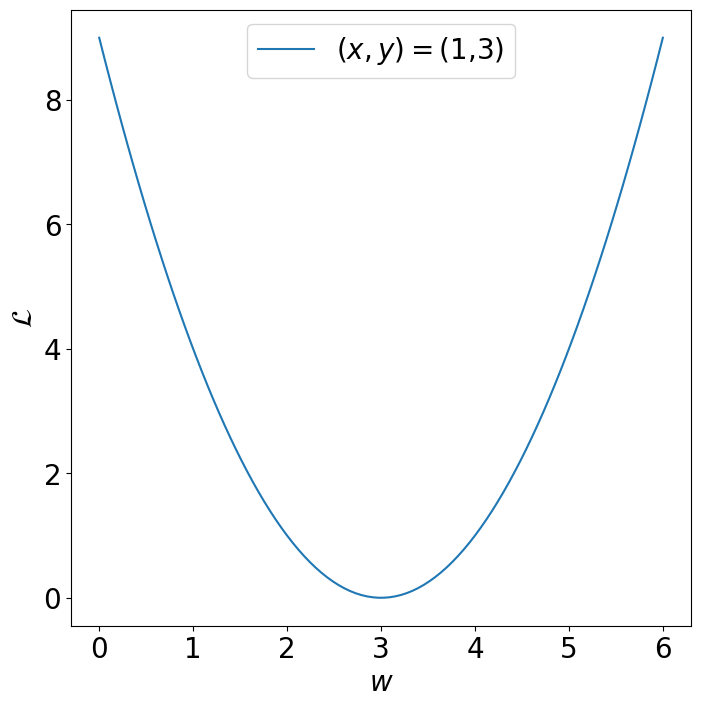

In [49]:
##### Start Your Code(Data Sample) #####
x1 = 1
y1 = 3 * x1
##### End Your Code(Data Sample) #####

##### Start Your Code(Loss Function) #####
w_range = np.linspace(0, 6, 100)
pred = (w_range * x1) - y1
loss = np.power(pred, 2)
##### End Your Code(Loss Function) #####

fig, ax = plt.subplots(figsize = (8,8))
ax.plot(w_range, loss,
        label = r'$(x,y) = ($' + str(x1) + ',' + str(y1)+ ')')
ax.tick_params(axis = 'both', labelsize = 20)
ax.set_xlabel(r'$w$', fontsize = 20)
ax.set_ylabel(r'$\mathcal{L}$', fontsize = 20)
ax.legend(loc = 'upper center', fontsize = 20)

**Expected Output**  
<img src='./imgs/3_02_01.png' width = 400>

위의 loss function에서 loss가 최소가 되는 $w$가 target function의 weight와 같음을 확인하세요.  
따라서 data sample을 가장 잘 표현하는 $w$는 loss function을 최소화시키는 3이 됩니다.

***
**Programming**

앞으로의 코드 중복을 방지하기 위하여 위의 loss function을 그리는 코드를 함수로 만들어줍니다.  
이때, loss function을 그려줄 axes도 argument로 받아주도록 합니다.

(Hint.1) 함수 몸체의 상단에 $w$에 따른 손실(loss)을 계산하는 코드를 포함합니다.  
(Hint.2) 함수 몸체의 하단에 손실을 그래프로 그리는 코드를 포함합니다.

In [50]:
def plot_loss_func(x, y, ax):
    ##### Start Your Code(Loss Function Functionalization) #####
    w_range = np.linspace(0, 6, 100)
    pred = (w_range * x) - y
    loss = np.power(pred, 2)

    ax.plot(w_range, loss,
            label = r'$(x,y) = ($' + str(x) + ',' + str(y)+ ')')
    ax.tick_params(axis = 'both', labelsize = 20)
    ax.set_xlabel(r'$w$', fontsize = 20)
    ax.set_ylabel(r'$\mathcal{L}$', fontsize = 20)
    ax.legend(loc = 'upper center', fontsize = 20)
    ##### End Your Code(Loss Function Functionalization) #####

***
## Step.2 Learning with One Sample

위의 x1, y1를 이용하여 predictor를 학습시켜봅니다.  
data sample이 하나이므로 epoch보단 iteration이라는 표현이 적절하므로 이전 실습(02)에서의 epochs을 iterations으로 고쳐줍니다.  

***
**Programming**  
~~이 학습을 위한 코드는 이전 실습(02)과 변수명 외에 달라지는 것은 없습니다.~~  
초기 $w$는 0.1, learning rate은 0.01, total iteration은 500으로 설정하세요.


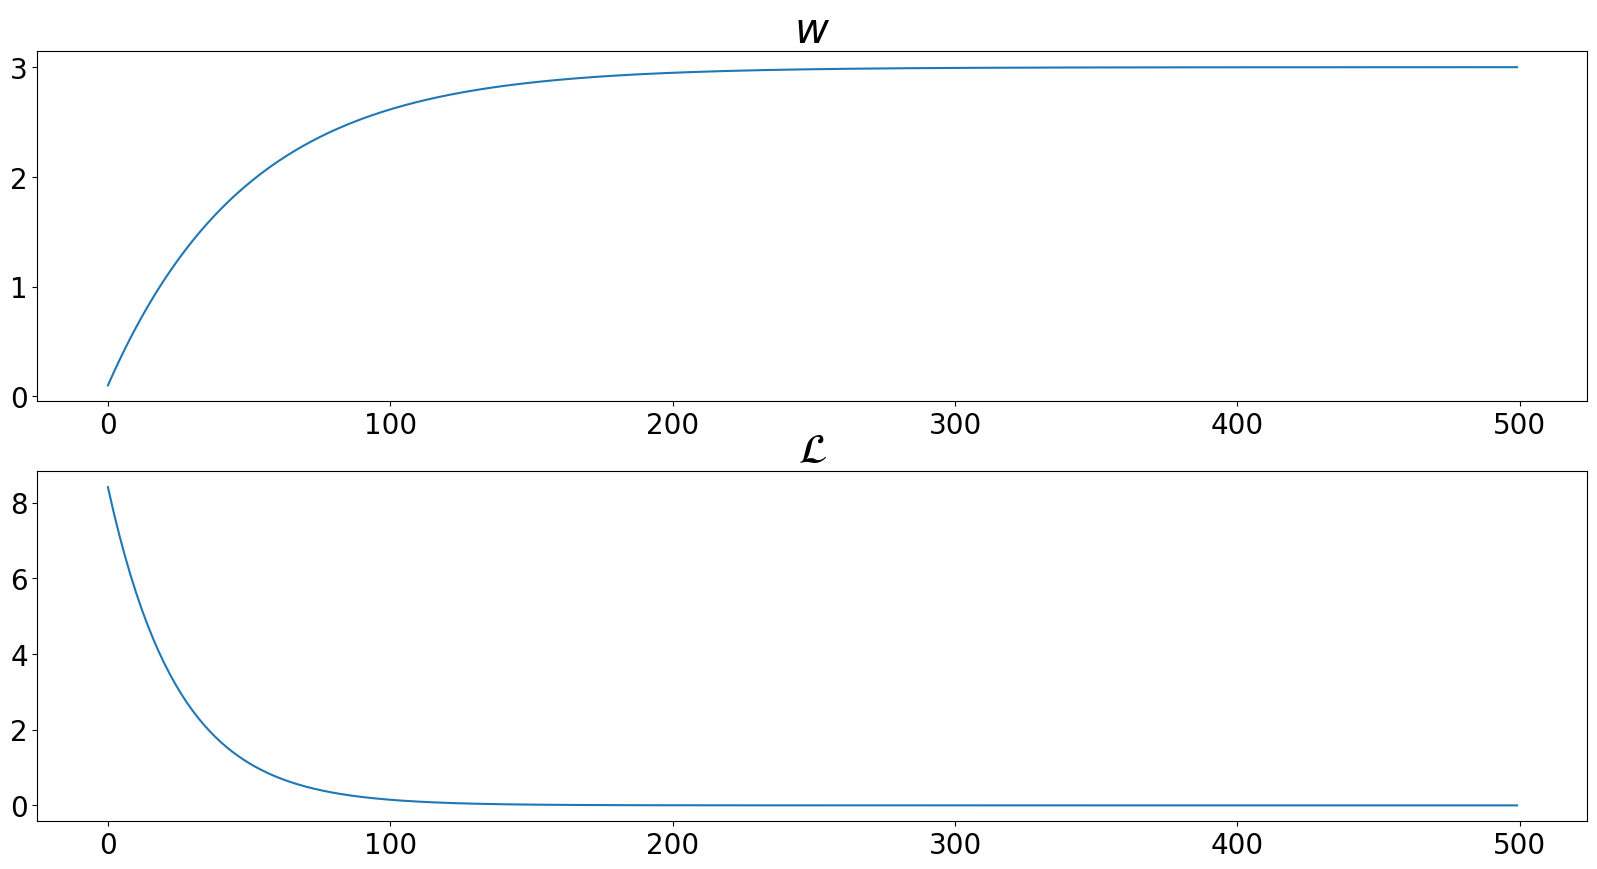

In [51]:
##### Start Your Code(Learning Preparation) #####
w = 0.1
lr = 0.01
iterations = 500
##### End Your Code(Learning Preparation) #####

w_list = []
loss_list = []

for iteration in range(iterations):
    ##### Start Your Code(Loss Calculation) #####
    pred = w * x1
    loss = (pred - y1) ** 2
    ##### End Your Code(Loss Calculation) #####

    w_list.append(w)
    loss_list.append(loss)
    
    ##### Start Your Code(Gradient Descent Method) #####
    w = w - ((2 * lr * x1) * (pred - y1))
    ##### End Your Code(Gradient Descent Method) #####
    
fig, ax = plt.subplots(2, 1, figsize = (20,10))
ax[0].plot(w_list)
ax[1].plot(loss_list)
ax[0].set_title(r'$w$', fontsize = 30)
ax[1].set_title(r'$\mathcal{L}$', fontsize = 30)
for ax_idx in range(2):
    ax[ax_idx].tick_params(axis = 'both', labelsize = 20)

**Expected Output**
<img src='./imgs/3_02_02.png' width=600>

***
**Programming**  
위의 코드도 중복사용을 피하기 위해 함수로 만들어줍니다.

trainer 함수는 iteration, learning rate 및 x, y값을 전달받아 w_list, loss_list를 반환합니다.

In [52]:
def trainer(iterations, lr, x, y):
    ##### Start Your Code(Trainer Function Functionalization) #####
    w = 0.1

    w_list = []
    loss_list = []

    for iteration in range(iterations):
        pred = w * x
        loss = (pred - y) ** 2

        w_list.append(w)
        loss_list.append(loss)
        
        w = w - ((2 * lr * x) * (pred - y))
    ##### Start Your Code(Trainer Function Functionalization) #####
    
    return w_list, loss_list

***
**Programming**  
위에서 만든 2개의 함수를 이용하여 학습 코드를 단순화해봅니다.

이때 위의 상황과 마찬가지고 iteration은 500, learning rate은 0.01로 설정합니다.

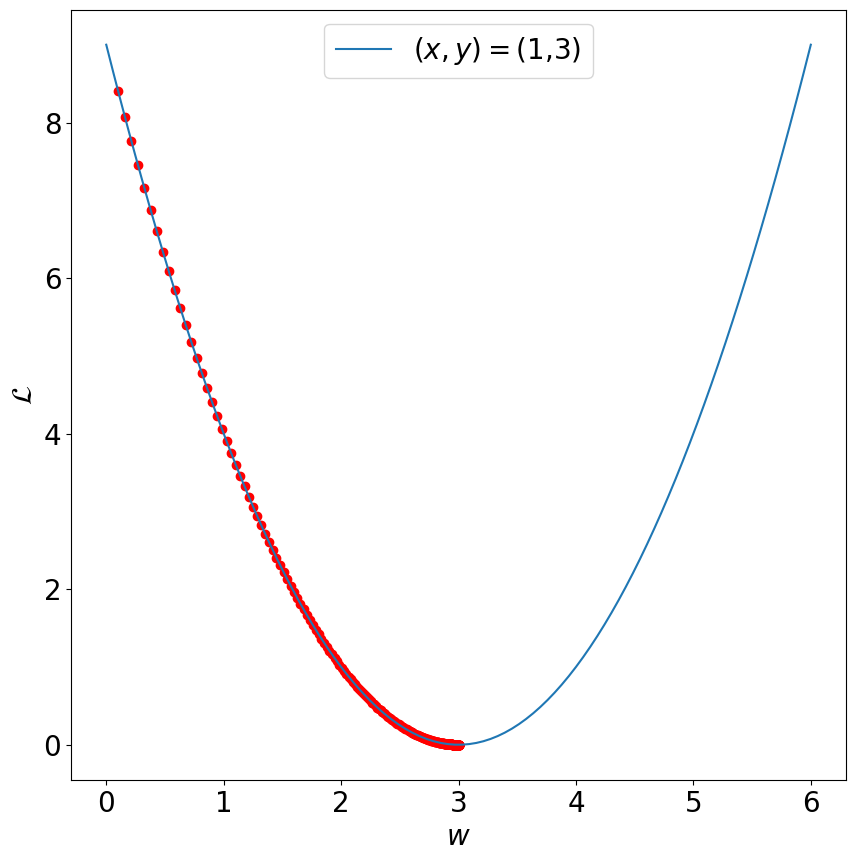

In [53]:
##### Start Your Code(Data Sample) #####
x1 = 1
y1 = 3 * x1
##### End Your Code(Data Sample) #####

fig, ax = plt.subplots(figsize = (10,10))

##### Start Your Code(Loss Function Visualization) #####
plot_loss_func(x1, y1, ax)
##### End Your Code(Loss Function Visualization) #####


##### Start Your Code(Training) #####
w_list, loss_list = trainer(500, 0.01, x1, y1)
##### End Your Code(Training) #####

ax.scatter(w_list, loss_list, color = 'r')

**Expected Output**
<img src='./imgs/3_02_03.png' width = 400>

***
## Step.3 Cost Functions for Different Data Samples

위의 함수 2개로 학습을 확인한 코드를 이용하여 다른 data sample에 대해서도 학습을 시켜봅니다.

***
**Programming**  
이번에는 동일한 target function $y = 3x$에서 만들어진 $(x^{(1)},y^{(1)}) = (2,6)$에 대해 학습을 진행해봅니다.  
학습을 진행한 후, $(x^{(1)},y^{(1)}) = (1,3)$을 이용한 학습과의 차이점을 분석해보길 바랍니다.

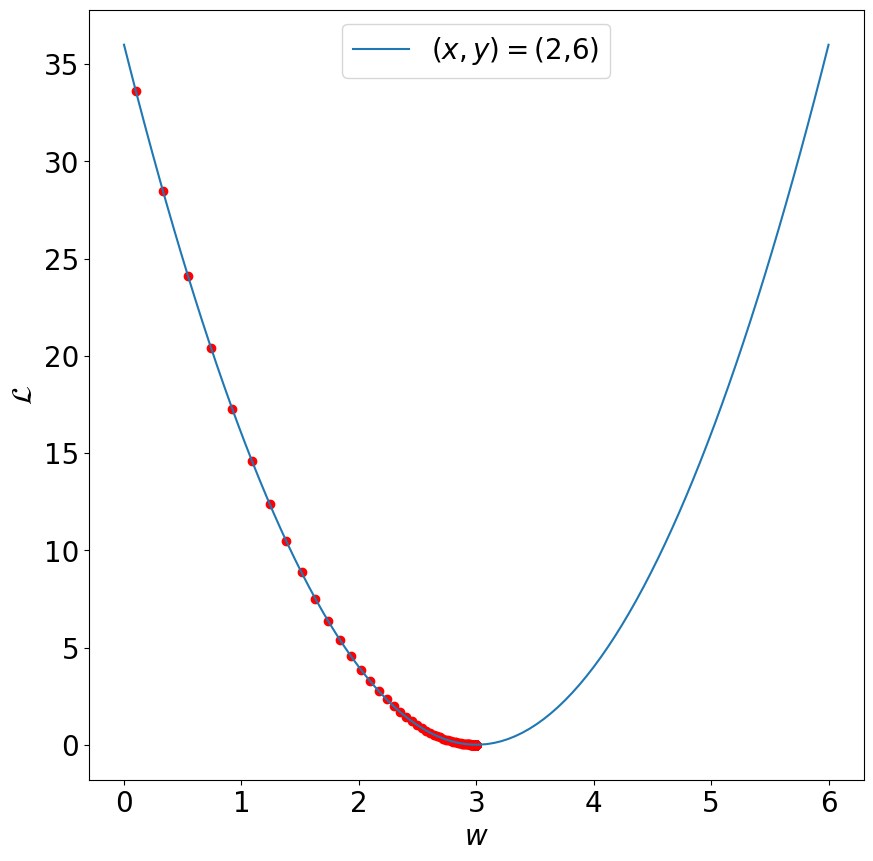

In [54]:
##### Start Your Code(Data Sample) #####
x2 = 2
y2 = 3 * x2
##### End Your Code(Data Sample) #####

fig, ax = plt.subplots(figsize = (10,10))

##### Start Your Code(Loss Function Visualization) #####
plot_loss_func(x2, y2, ax)
##### End Your Code(Loss Function Visualization) #####


##### Start Your Code(Training) #####
w_list, loss_list = trainer(500, 0.01, x2, y2)
##### End Your Code(Training) #####

ax.scatter(w_list, loss_list, color = 'r')

**Expected Output**
<img src='./imgs/3_02_04.png' width = 400>

***
## Step.4 Learning with Different Data Samples

위의 내용을 바탕으로 3개의 data sample들 
$$ \{(x^{(1)},y^{(1)}), (x^{(2)},y^{(2)}), (x^{(3)},y^{(3)})\} = \{(0.5,1.5), (1,3), (2,6)\} $$
에 대해 학습이 진행되는 모습을 비교해봅니다.

***
**Programming**  
아래의 코드는 같은 axes에 3개의 data sample들에 대해 $w$가 update되는 모습을 비교하기 위한 코드입니다.

이때 iteration은 20, learning rate은 0.1로 설정해줍니다.

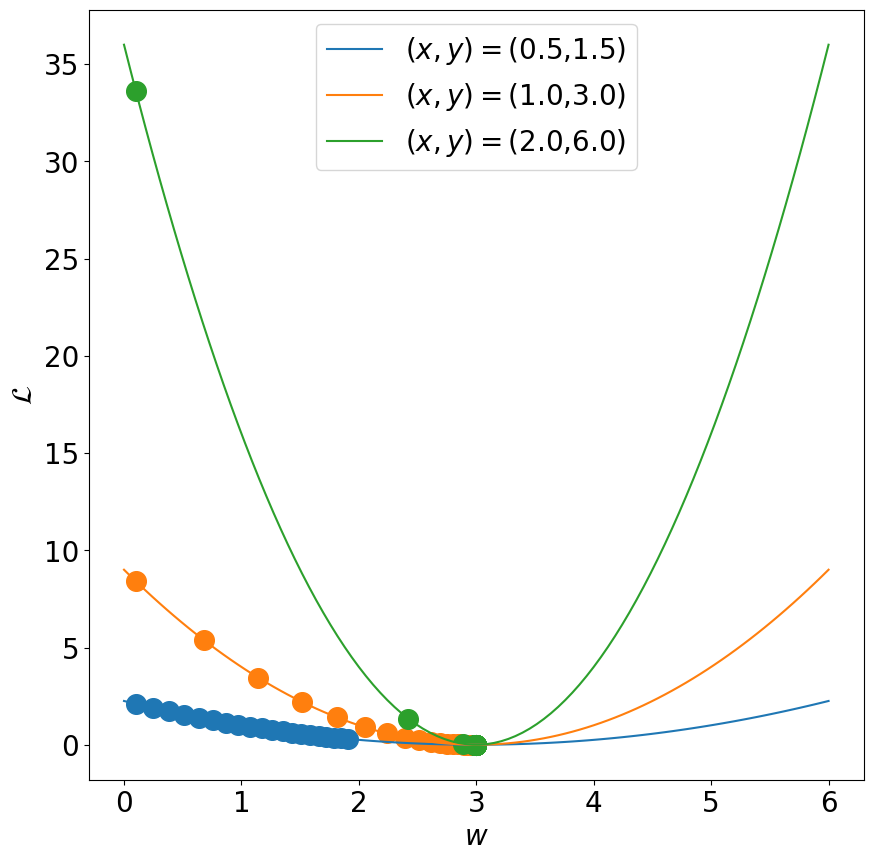

In [55]:
x_data = np.array([0.5, 1, 2])
y_data = 3*x_data

fig, ax = plt.subplots(figsize = (10,10))

for x, y in zip(x_data, y_data):
    ##### Start Your Code(Loss Funtion and Training) #####
    plot_loss_func(x, y, ax)
    w_list, loss_list = trainer(20, 0.1, x, y)
    
    ##### Start Your Code(Loss Funtion and Training) #####
    ax.scatter(w_list, loss_list, s = 200)

**Expected Output**
<img src='./imgs/3_02_05.png' width = 400>

***
## Step.5 Learning with Dataset

실제 딥러닝에서는 하나의 data sample만을 이용해 학습을 하지 않고, dataset 안에 들어있는 다양한 data sample들을 이용하여 학습합니다.  
이번에는 dataset에 포함된 3개의 data sample을 모두 사용하여 $w$를 학습시키는 방법을 알아봅니다.

***
**Programming**  
Dataset에서 data sample을 한 개씩 선택하여 gradient descent method를 이용하여 $w$를 학습시킵니다.

(Hint.1) 초기 $w$는 0.1, learning rate은 0.01, epochs은 5로 설정합니다.  
(Hint.2) 위에서 만든 함수를 사용하는 것이 아니라 이전 실습(032_02)처럼 loss를 구한 후에 gradient descent method를 사용하여 학습을 진행합니다.  

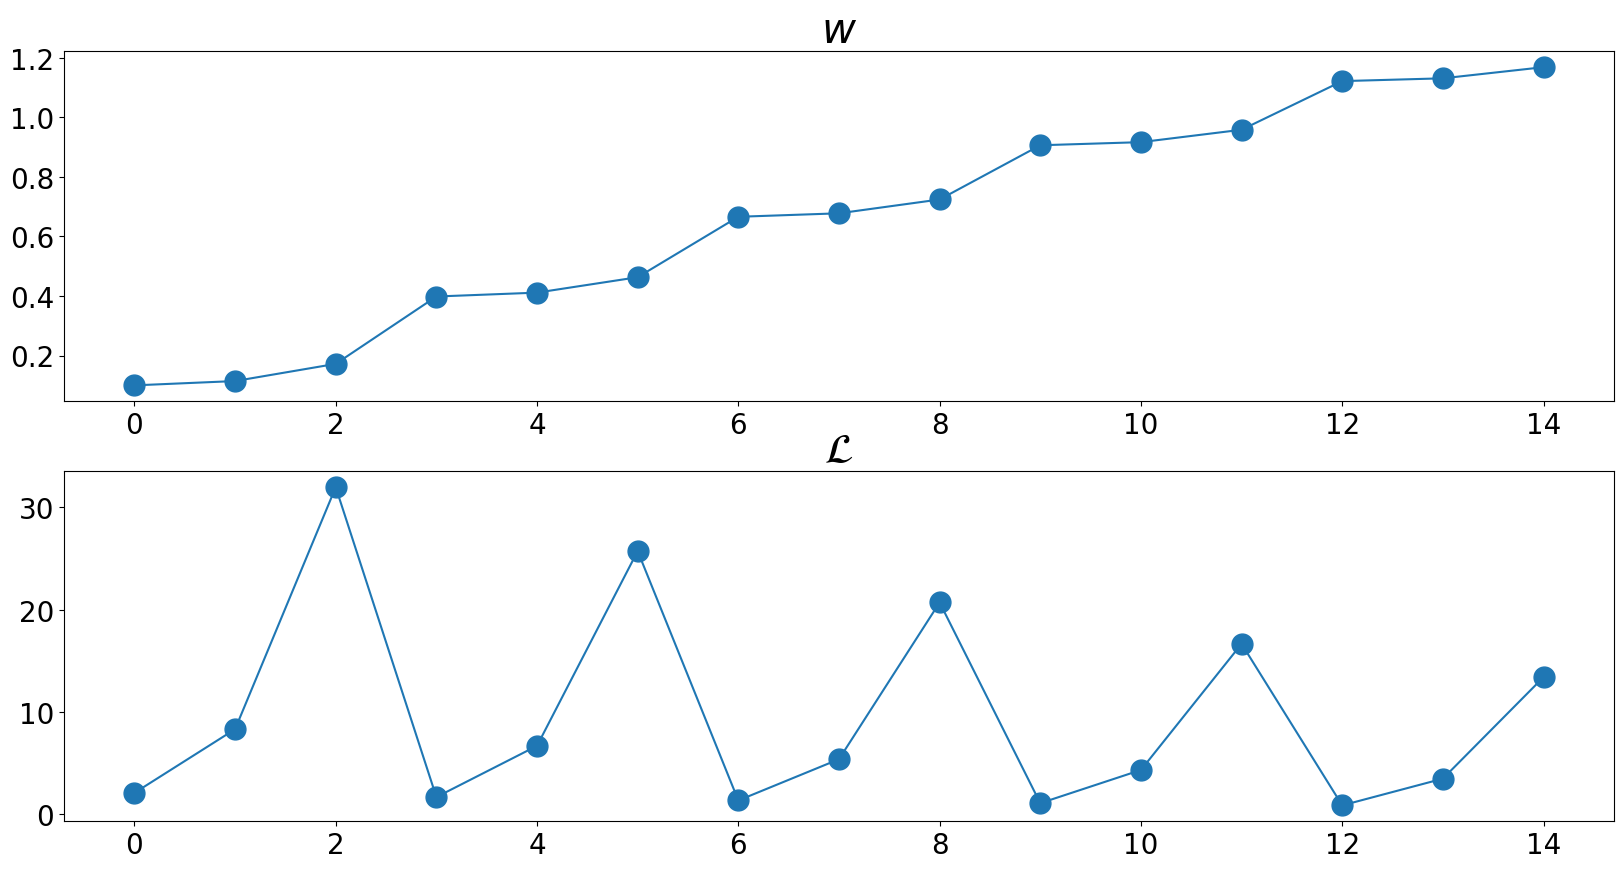

In [56]:
x_data = np.array([0.5, 1, 2])
y_data = 3*x_data

##### Start Your Code(Learning Preparation) #####
w = 0.1
lr = 0.01
epochs = 5
##### End Your Code(Learning Preparation) #####

w_list = []
loss_list = []
    
for epoch in range(epochs):
    for x,y in zip(x_data, y_data):
        ##### Start Your Code(Loss Calculation) #####
        pred = w * x
        loss = (pred - y) ** 2
        ##### End Your Code(Loss Calculation) #####
        
        w_list.append(w)
        loss_list.append(loss)
        
        ##### Start Your Code(Gradient Descent Method) #####
        w = w - ((2 * lr * x) * (pred - y))
        ##### End Your Code(Gradient Descent Method) #####
        
fig, ax = plt.subplots(2, 1, figsize = (20,10))
ax[0].plot(w_list, marker = 'o', markersize = 15)
ax[1].plot(loss_list, marker = 'o', markersize = 15)
ax[0].set_title(r'$w$', fontsize = 30)
ax[1].set_title(r'$\mathcal{L}$', fontsize = 30)
for ax_idx in range(2):
    ax[ax_idx].tick_params(axis = 'both', labelsize = 20)

**Expected Output**
<img src='./imgs/3_02_06.png' width = 600>

***
## Step.6 Random Shuffling

실제 딥러닝 프로젝트에서는 dataset 전체를 이용하여 학습을 시킨 뒤, data sample의 순서를 바꿔줍니다.  
이를 통해 $w$에 대한 규칙적인 update를 막을 수 있습니다.

***
**Programming**  
위에 작성한 학습 코드를 그대로 이용하되, epoch마다 random shuffle을 이용하여 학습을 진행하고,  
random shuffle의 유무에 따라 학습의 경향이 어떻게 바뀌는지 분석해보세요. (기대 출력과 그래프의 형태를 달라질 수 있습니다.)  

(Hint.1) np.random.shuffle()을 사용하여 shuffling 수행합니다.  
(Hint.2) 위에서 만든 함수를 사용하는 것이 아니라 이전 실습(02)처럼 loss를 구한 후에 gradient descent method를 사용하여 학습을 진행합니다.  

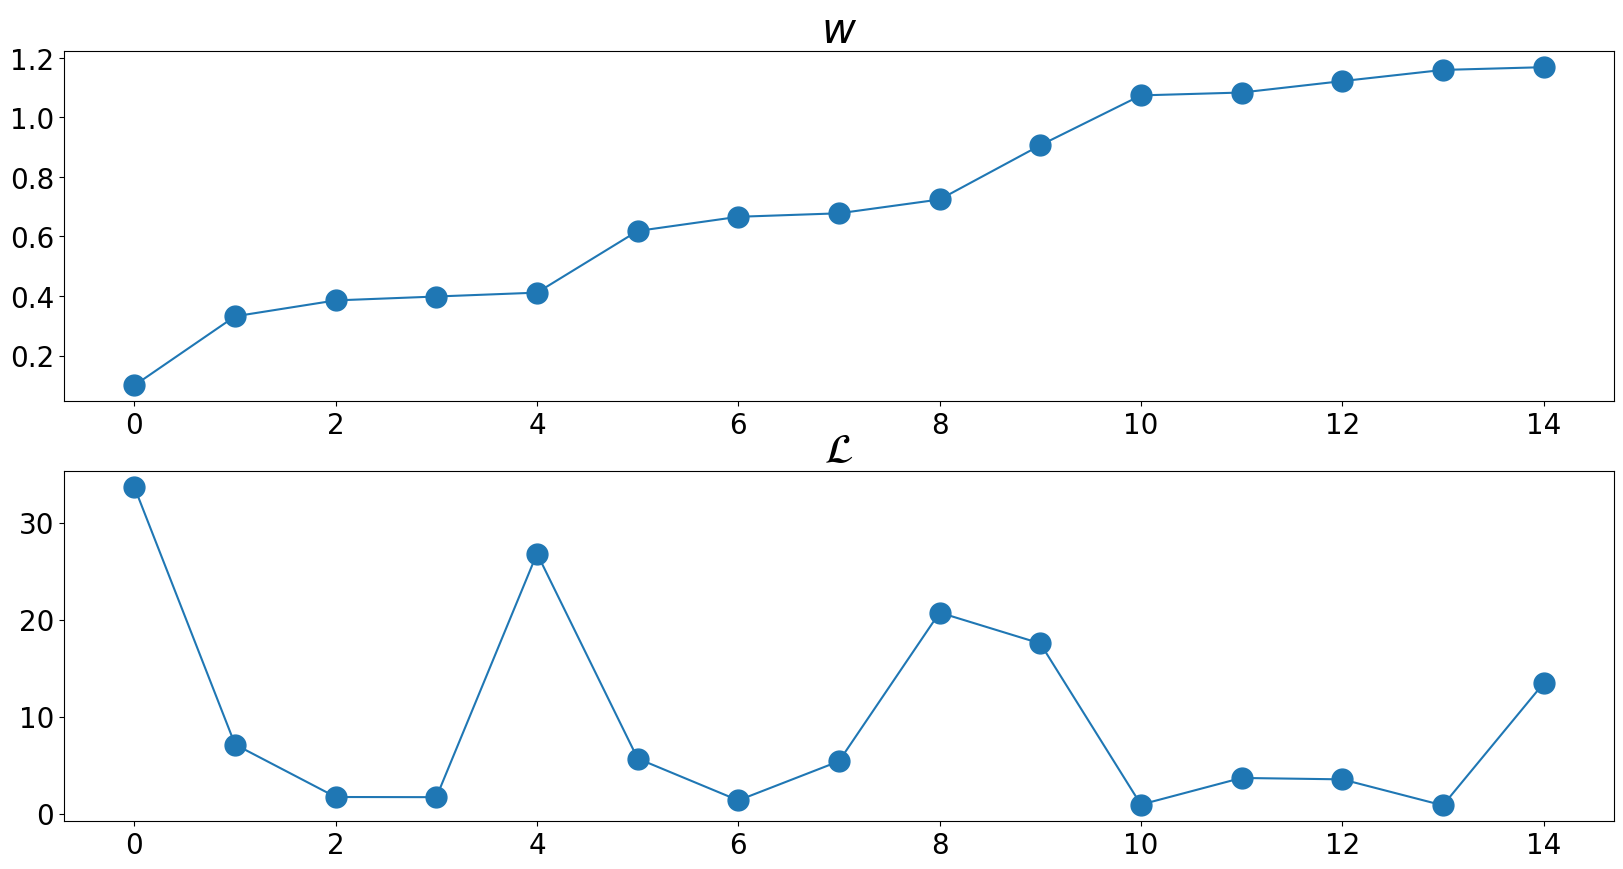

In [57]:
x_data = np.array([0.5, 1, 2]).reshape(-1,1)
y_data = 3*x_data

data = np.hstack((x_data, y_data))

##### Start Your Code(Learning Preparation) #####
w = 0.1
lr = 0.01
epochs = 5
##### End Your Code(Learning Preparation) #####

w_list = []
loss_list = []
    
for epoch in range(epochs):
    ##### Start Your Code(shuffling) #####
    np.random.shuffle(data)
    ##### End Your Code(shuffling) #####
    for x,y in data:
        ##### Start Your Code(Loss Calculation) #####
        pred = w * x
        loss = (pred - y) ** 2
        ##### End Your Code(Loss Calculation) #####
        
        w_list.append(w)
        loss_list.append(loss)
        
        ##### Start Your Code(Gradient Descent Method) #####
        w = w - ((2 * lr * x) * (pred - y))
        ##### End Your Code(Gradient Descent Method) #####
        
fig, ax = plt.subplots(2, 1, figsize = (20,10))
ax[0].plot(w_list, marker = 'o', markersize = 15)
ax[1].plot(loss_list, marker = 'o', markersize = 15)
ax[0].set_title(r'$w$', fontsize = 30)
ax[1].set_title(r'$\mathcal{L}$', fontsize = 30)
for ax_idx in range(2):
    ax[ax_idx].tick_params(axis = 'both', labelsize = 20)

**Expected Output**
<img src='./imgs/3_02_07.png' width = 600>